In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse.linalg import expm_multiply, spsolve, norm, expm
from utils import *
# from ionq_circuit_utils import *

from os.path import join
import json

from random import seed

from qiskit import QuantumCircuit, transpile
from qiskit import Aer

from scipy.sparse import diags

from simuq import QSystem
from simuq import Qubit
from simuq.ionq import IonQProvider, IonQAPICircuit

from os import getenv
from dotenv import load_dotenv

load_dotenv()
IONQ_API_KEY = getenv('IONQ_API_KEY')

In [3]:
def get_cdf(c_normalized):
    '''Returns the cumulative distribution function for distribution c'''
    assert np.abs(np.sum(c_normalized) - 1) < 1e-5
    cdf = np.zeros_like(c_normalized)
    cdf[0] = c_normalized[0]
    for i in np.arange(1, len(c_normalized)):
        cdf[i] = cdf[i-1] + c_normalized[i]
    return cdf

def sample_from_dist(cdf):
    '''Returns a random index with probability proportional to the distribution according to cdf'''
    u = np.random.rand()
    return np.argmax(u < cdf)

def hamming_weight(bitstring):
    weight = 0
    for bit in bitstring:
        if bit == "1":
            weight += 1
    return weight

def get_gate_counts(ionq_circuit):
    one_qubit_gates = 0
    two_qubit_gates = 0
    for instruction in ionq_circuit:
        if instruction["gate"] == "ms":
            two_qubit_gates += 1
        else:
            one_qubit_gates += 1
    return one_qubit_gates, two_qubit_gates

Let $H_{\text{TFIM}} = J\sum_{i=0}^{n-2} Z_j Z_{j+1} + h\sum_{i=0}^{n-1} X_j$.

We consider the non-Hermitian Hamiltonian
$$
H = H_{\text{TFIM}} + i\gamma \sum_{j=0}^{n-1} (Z_j - I).
$$

# Experiment parameters

In [4]:
# Experiment parameters
n = 2
J = 1
h = -1
gamma = 1                                                # Coefficient for anti-Hermitian part
K = 5                                                    # Right side of bounary
M = 128
T = 1
num_time_points = 8
r = 4                                                     # Trotter steps (should scale with K)
t_vals = np.linspace(0, T, num_time_points)
num_shots = 100
num_samples = 200
print(f"Number of jobs: {num_time_points * num_samples}")
print(f"Estimated cost if using AWS: {num_time_points * num_samples * (0.3 + num_shots * 0.03)}")

experiment_info = {
    "n": n,
    "J": J,
    "h": h,
    "gamma": gamma,
    "K": K,
    "M": M,
    "T": T,
    "num_time_points": num_time_points,
    "r": r,
    "num_shots": num_shots,
    "num_samples": num_samples
}


Number of jobs: 1600
Estimated cost if using AWS: 5280.0


Ground truth

In [5]:
H = h * sum_x(n) + J * sum_J_zz(n, diags([np.ones(n-1), np.ones(n-1)], [1,-1]).toarray()) \
      - 1j * (sum_delta_n(n, delta=2 * gamma * np.ones(n)))

psi_0 = np.zeros(2 ** n)
psi_0[0] = 1
# psi_0 = np.ones(2 ** n)
# psi_0 /= np.linalg.norm(psi_0)

In [6]:
psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_time_points)

We test the observable $\sum_{j=0}^{n-1} \frac{I-Z_j}{2}$.

In [7]:
obs_gt = np.zeros(num_time_points)
for i in range(num_time_points):
    obs_gt[i] = np.real(np.conj(psi[i]) @ sum_delta_n(n, np.ones(n)) @ psi[i])

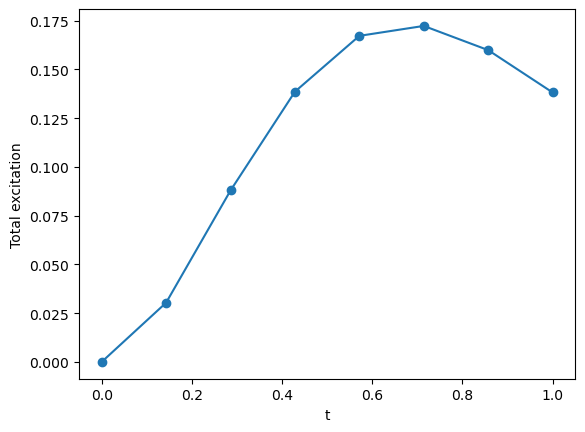

In [8]:
plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.ylabel("Total excitation")
plt.xlabel("t")
plt.show()

Create the circuits $\bra{\psi_0} U_{k_j}(t)^\dagger OU_{k_j}(t)\ket{\psi_0}$

In [1]:
def simuq_diagonal_terms(n, k, t, J, h, gamma):
    qs = QSystem()
    q = [Qubit(qs) for _ in range(n)]
    H = 0

    for j in range(n):
        H += h * q[j].X
    for j in range(n-1):
        H += J * q[j].Z * q[j+1].Z
    for j in range(n):
        H += - gamma * k * q[j].Z
    qs.add_evolution(H, t)
    return qs


def simuq_off_diagonal_terms(n, k1, k2, t, J, h, gamma):
    qs = QSystem()
    q = [Qubit(qs) for _ in range(n+1)]
    H = 0

    # TFIM part
    for j in range(n):
        H += h * q[j+1].X
    for j in range(n-1):
        H += J * q[j+1].Z * q[j+2].Z

    # # Projectors onto \ket{0} and \ket{1}
    p0 = (q[0].I + q[0].Z) / 2
    p1 = (q[0].I - q[0].Z) / 2

    for j in range(n):
        H += 2 * gamma * (k1 * p0 * (q[j+1].I - q[j+1].Z) / 2) + (k2 * p1 * (q[j+1].I - q[j+1].Z) / 2)

    qs.add_evolution(H, t)
    return qs

In [2]:
provider = IonQProvider(api_key=IONQ_API_KEY)

NameError: name 'IonQProvider' is not defined

In [11]:
'''Off-diagonal terms'''
hadamard_circ = IonQAPICircuit(experiment_info["n"]+1)
hadamard_circ.rz(0, np.pi)
hadamard_circ.gpi2(0, 0.25 * (2 * np.pi))

off_diagonal_qs = simuq_off_diagonal_terms(experiment_info["n"], K, -K, T, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])

provider.compile(off_diagonal_qs, trotter_mode=2, trotter_num=experiment_info["r"], state_prep=hadamard_circ.copy(), meas_prep=hadamard_circ.copy())
one_qubit_gates, two_qubit_gates = get_gate_counts(provider.prog["body"]["circuit"])
print(f"1q: {one_qubit_gates}, 2q: {two_qubit_gates}")

1q: 46, 2q: 24


In [13]:
provider.run()

{'id': 'd368ec61-9606-4265-8725-a97df367b927', 'status': 'ready', 'request': 1697477413}


'd368ec61-9606-4265-8725-a97df367b927'

Run on IonQ simulator

In [11]:
def run_lchs_simuq(experiment_info, on_simulator=True):
    np.random.seed(0)
    provider = IonQProvider(api_key=IONQ_API_KEY)
    t_vals = np.linspace(0, experiment_info["T"], experiment_info["num_time_points"])
    k = np.linspace(-experiment_info["K"], experiment_info["K"], experiment_info["M"], endpoint=False)
    c = 2 * experiment_info["K"] / (experiment_info["M"] * np.pi * (1 + k ** 2))
    cdf = get_cdf(c / np.sum(c))
    
    observable = np.zeros(len(t_vals))
    for i, t in enumerate(t_vals):

        print(f"Running t={t:0.2f}")

        sampled_indices = []
        for _ in range(experiment_info["num_samples"]):
            j1, j2 = sample_from_dist(cdf), sample_from_dist(cdf)
            sampled_indices.append((int(j1), int(j2)))

            if j1 == j2:
                '''Diagonal terms'''
                diagonal_qs = simuq_diagonal_terms(experiment_info["n"], k[j1], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])
                provider.compile(diagonal_qs, trotter_mode=2, trotter_num=experiment_info["r"])
            else:
                '''Off-diagonal terms'''
                hadamard_circ = IonQAPICircuit(experiment_info["n"]+1)
                hadamard_circ.rz(0, np.pi)
                hadamard_circ.gpi2(0, 0.25 * (2 * np.pi))

                off_diagonal_qs = simuq_off_diagonal_terms(experiment_info["n"], k[j1], k[j2], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])
                assert off_diagonal_qs.num_sites == len(hadamard_circ._accum_phases)
                provider.compile(off_diagonal_qs, trotter_mode=2, trotter_num=experiment_info["r"], state_prep=hadamard_circ.copy(), meas_prep=hadamard_circ.copy())
            
            # TODO: Save job ids

            # provider.run(shots=experiment_info["num_shots"], on_simulator=on_simulator)
            provider.run(num_shots, on_simulator=True)
            job_id = provider.task['id']
            # # job = backend.run(compiled_circuit)
            # freq = provider.results()
            
            # if j1 == j2:
            #     for string in freq.keys():
            #         assert len(string) == experiment_info["n"]
            #         bitstring = np.binary_repr(int(string, 2), experiment_info["n"])
            #         # Observable is Hamming weight
            #         observable[i] += hamming_weight(bitstring) * freq[string] / num_shots
            # else:
            #     zero_obs, one_obs = 0, 0
            #     for string in freq.keys():
            #         assert len(string) == experiment_info["n"] + 1
            #         bitstring = np.binary_repr(int(string, 2), experiment_info["n"] + 1)
            #         if bitstring[0] == '0':
            #             zero_obs += hamming_weight(bitstring[1:]) * freq[string]
            #         else:
            #             one_obs += hamming_weight(bitstring[1:]) * freq[string]
            #     observable[i] += (zero_obs - one_obs)
    
    observable *= (np.sum(c) ** 2) / experiment_info["num_samples"]
    print("Finished.")
    return observable

In [ ]:
observable = run_lchs(experiment_info)

In [124]:
observable_no_measurement_error = run_lchs(experiment_info, finite_samples=False)

Running t=0.00
Running t=0.10
Running t=0.20
Running t=0.30
Running t=0.40
Running t=0.50
Running t=0.60
Running t=0.70
Running t=0.80
Running t=0.90
Running t=1.00
Finished.


In [ ]:
plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.plot(t_vals, observable_no_measurement_error, '-o', label="Qiskit simulator (w/o measurement error)")
plt.plot(t_vals, observable, '-o', label=f"Qiskit simulator ({num_shots} shots per circuit)")
plt.ylabel("Expected Hamming weight")
plt.xlabel("t")
plt.legend()
plt.title(f"LCHS ({num_samples} samples for integration)")
plt.show()